# $w_0$–$\Omega_m$ Degeneracy in the Einstein Radius

This notebook illustrates the degeneracy between $w$ and $\Omega_m$ in the Einstein radius observable. For a fixed lens configuration ($z_s$, $\sigma_v$), the Einstein radius is constant along curves in ($w$, $\Omega_m$) space, plotted here as contours. The key result is that the orientation of these degeneracy curves shifts with lens and source configuration: two lenses at different redshifts trace different degeneracy directions, motivating the use of a population of lenses to break the degeneracy and constrain both parameters jointly.

In [1]:
import numpy as np
from astropy.cosmology import wCDM
import astropy.units as u
import matplotlib.pyplot as plt

In [2]:
# define your plot style

best_style = {
    "font.family": "sans-serif",
    "mathtext.fontset": "custom",
    "mathtext.rm": "TeX Gyre Heros",
    "mathtext.bf": "TeX Gyre Heros:bold",
    "mathtext.sf": "TeX Gyre Heros",
    "mathtext.it": "TeX Gyre Heros:italic",
    "mathtext.tt": "TeX Gyre Heros",
    "mathtext.cal": "TeX Gyre Heros",
    "mathtext.default": "regular",
    "figure.figsize": (10.0, 10.0),
    "font.size": 26,
    "axes.labelsize": "medium",
    "axes.unicode_minus": False,
    "xtick.labelsize": "small",
    "ytick.labelsize": "small",
    "legend.fontsize": "small",
    "legend.handlelength": 1.5,
    "legend.borderpad": 0.5,
    "xtick.direction": "in",
    "xtick.major.size": 12,
    "xtick.minor.size": 6,
    "xtick.major.pad": 6,
    "xtick.top": True,
    "xtick.major.top": True,
    "xtick.major.bottom": True,
    "xtick.minor.top": True,
    "xtick.minor.bottom": True,
    "xtick.minor.visible": True,
    "ytick.direction": "in",
    "ytick.major.size": 12,
    "ytick.minor.size": 6.0,
    "ytick.right": True,
    "ytick.major.left": True,
    "ytick.major.right": True,
    "ytick.minor.left": True,
    "ytick.minor.right": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.8,
    "grid.linestyle": ":",
    "axes.linewidth": 2,
    "savefig.transparent": False,
}
plt.style.use(best_style)
cols = ["#5790fc", "#f89c20", "#009e73", "#964a8b", "#e42536", "#9c9ca1", "#7a21dd"]
# add a new color blind friendly color to this list
#set cols as the matplotlib default color cycle
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=cols)

In [3]:
figpath = f'/home/jarugula/nre_wom/proj_cosmo_nre/src/scripts/evaluate/mcmc/plots/'

In [4]:
G = 6.67384 * 10 ** (-11)  # Gravitational constant [m^3 kg^-1 s^-2]
c = 299792458  # [m/s]

M_sun = 1.9891 * 10**30  # solar mass in [kg]
M_earth = 5.9972 * 10**24  # Earth mass in [kg]
M_jupiter = 1.89813 * 10**27  # Jupiter mass in [kg]
AU = 1.495978707 * 10**11  # Distance Earth Sun (Astronomical unit) in [m]

Mpc = 3.08567758 * 10**22  # Mpc in [m]
kpc = 3.08567758 * 10**19  # kpc in [m]
pc = 3.08567758 * 10**16  # pc in [m]
r_sun = 6.96000 * 10**8  # radius of the sun in [m]

day_s = 24 * 3600  # day in second
arcsec = 2 * np.pi / 360 / 3600  # arc second in radian

In [5]:
def d_xy(cosmo, z_observer, z_source):
    """

    :param z_observer: observer redshift
    :param z_source: source redshift
    :return: angular diameter distance in units of Mpc
    """
    D_xy = cosmo.angular_diameter_distance_z1z2(z_observer, z_source)
    return D_xy.value

def dd(cosmo, z_lens):
    """
    :return: angular diameter distance to the deflector [Mpc]
    """
    return d_xy(cosmo, 0.0, z_lens)

def ds(cosmo, z_source):
    """

    :return: angular diameter distance to the source [Mpc]
    """
    return d_xy(cosmo, 0.0, z_source)

def dds(cosmo, z_lens, z_source):
    """

    :return: angular diameter distance from deflector to source [Mpc]
    """
    return d_xy(cosmo, z_lens, z_source)

In [6]:
# Returns Einstein radius in arcseconds (divided by 1e-6 to convert from microarcsec).
@np.vectorize
def einstein_radius(w, om, zl, zs, v):
    cosmo = wCDM(H0=70, Om0=om, Ode0=(1-om), w0=w)
    dls = dds(cosmo, zl, zs)
    d_src = ds(cosmo, zs)
    theta = 4*np.pi*(v**2)*dls/(c**2 * d_src)
    theta = theta/arcsec
    return theta/1e-6

In [7]:
w_list = np.linspace(-1.8, -0.4, 200)
om_list = np.linspace(0.1, 0.9, 200)

# meshgrid
X,Y = np.meshgrid(w_list, om_list)
X = X.T
Y = Y.T

In [8]:
# Two lens configurations with the same (zs, sigma_v) but different zl.
# The D_ls/D_s ratio which controls how the Einstein radius depends on cosmology, 
# changes with zl, so the two configurations trace different degeneracy directions in (w, Om) space.
zl1 = 0.1
zl2 = 0.8
zs = 2.0
v = 275

Z1 = einstein_radius(X, Y, zl1, zs, v)
Z2 = einstein_radius(X, Y, zl2, zs, v)

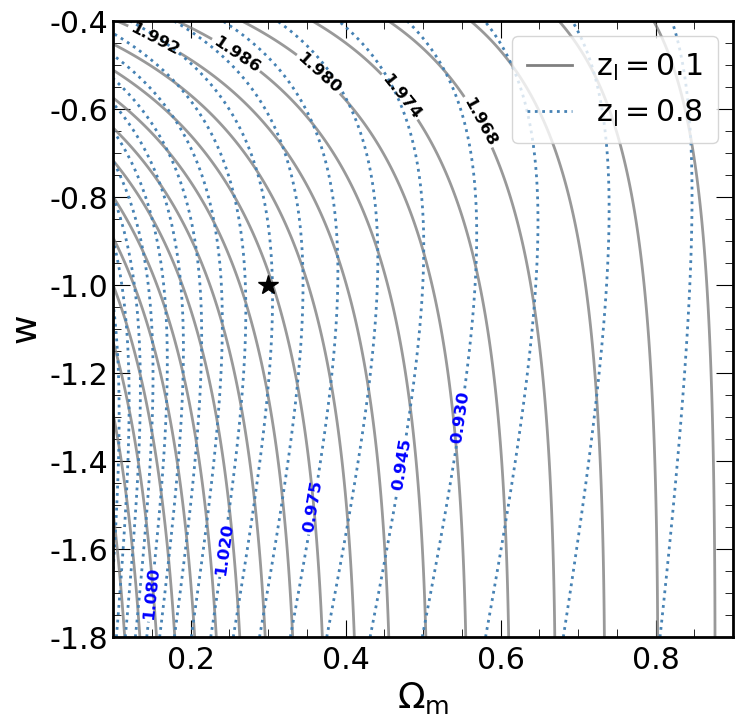

In [16]:
# Plot the contours of the Einstein radius for the two lens configurations
fig, ax = plt.subplots(figsize=(8, 8))
CS1 = ax.contour(Y, X, Z1, levels=20, colors='grey', alpha=0.8, linewidths=2.0, linestyles='-')
CS2 = ax.contour(Y, X, Z2, levels=20, colors='steelblue', alpha=1.0, linewidths=2.0, linestyles=':')
labels1 = ax.clabel(CS1, inline=1, fontsize=12, fmt='%1.3f', manual=[(0.15, -0.45), (0.25, -0.5), (0.35, -0.55), (0.45, -0.6), (0.55, -0.65)])
labels2 = ax.clabel(CS2, inline=1, fontsize=12, fmt='%1.3f', manual=[(0.15, -1.7), (0.25, -1.6), (0.35, -1.5), (0.45, -1.4), (0.55, -1.3)])
for txt in labels1:
    txt.set_color('k')
    txt.set_fontweight('bold')
for txt in labels2:
    txt.set_color('blue')
    txt.set_fontweight('bold')
# add a black star at (0.3, -1.0)
ax.plot(0.3, -1.0, marker='*', color='black', markersize=15)
contour1 = plt.Line2D([], [], color='grey', linestyle='-', linewidth=2, label=r'$z_{l}=0.1$')
contour2 = plt.Line2D([], [], color='steelblue', linestyle=':', linewidth=2, label=r'$z_{l}=0.8$')
ax.legend(handles=[contour1, contour2], loc='upper right')
ax.set_ylabel('$w$')
ax.set_xlabel('$\Omega_m$')
# plt.show()
fig.savefig(f'{figpath}w0_Om0_degeneracy_single.pdf', dpi=300)
